# Genomic Variant Integration and Annotation Pipeline
This project builds a data pipeline to integrate clinical and genomic variant data from ClinVar and Ensembl, enabling downstream analysis and visualization of mutation patterns across genes.  
  
  **Raul Garcia, ISTA 322 May 6, 2023**

## Data Sources

This project integrates data from two primary sources:

**ClinVar (NCBI API)**  
https://clinicaltables.nlm.nih.gov/apidoc/variants/v4/doc.html  
Used to extract variant-level clinical data.

**Ensembl REST API (GRCh37)**  
https://rest.ensembl.org  
Used to retrieve genomic annotations for each variant.

Due to API rate limits and dataset size, Ensembl data were retrieved using a batching pipeline.

In [1]:
import requests
import json
import pandas as pd
from pandas.errors import EmptyDataError
import os
import time
import sqlite3
import matplotlib.pyplot as plt

### Execution Control

Set RUN_ENSEMBL = True to rerun the Ensembl API extraction (~1.5 hours).
Default is False to load precomputed data for faster execution.

In [2]:
# Runtime control
RUN_ENSEMBL = False

In [3]:
PROJECT_FOLDER = '.'

In [4]:
os.makedirs(PROJECT_FOLDER, exist_ok=True)

CLINVAR_FOLDER = f'{PROJECT_FOLDER}/clinvar'
ENSEMBL_FOLDER = f'{PROJECT_FOLDER}/ensembl'

os.makedirs(CLINVAR_FOLDER, exist_ok=True)
os.makedirs(ENSEMBL_FOLDER, exist_ok=True)

# I. Extraction Phase

## ClinVar section

In [5]:
CLINVAR_BASE_URL = "https://clinicaltables.nlm.nih.gov/api/variants/v4/search"

### Extract variants from ClinVar

In [6]:
# ClinVar extraction
def extract_var(gene: str, count: int = 350) -> list[str]:
  # query string parameters
  params = {"terms" : gene, "count" : count}
  response = requests.get(
    CLINVAR_BASE_URL,
    params=params,
    timeout=15
)

  if not response.ok:
    return []

  variants = []
  for item in response.json()[3]:
    var = item[1]
    # Extract HGVS portion (remove protein annotation)
    var_string = var.split()[0].strip()
    variants.append(var_string)
  return variants

### Build the combined variant list

In [7]:
# Building variants from the genes indicated
genes = ["BRCA1", "BRCA2", "TP53"]
all_variants = []

for gene in genes:
  all_variants.extend(extract_var(gene))

### Filtering out variants that are unusable or that result in more than a single change

In [8]:
clean_variants = []
excluded_variants = []

for v in all_variants:
  if (
      '[' in v or
      ']' in v or
      ';' in v or
      '?' in v or
      'delins' in v or
      len(v) > 100
      ):
    excluded_variants.append(v)
  else:
    clean_variants.append(v)

print("Clean:", len(clean_variants))
print("Excluded:", len(excluded_variants))


Clean: 1016
Excluded: 34


### Building ClinVar dataframe and saving to project folder

In [9]:
# Build Clinvar dataframe and save to project folder
clinvar_df = pd.DataFrame(clean_variants, columns=['input'])
clinvar_df.to_csv(
    f'{CLINVAR_FOLDER}/clinvar_clean_variants.csv',
    index=False
)

print('Saved ClinVar dataset shape', clinvar_df.shape)
clinvar_df.head()

Saved ClinVar dataset shape (1016, 1)


,input
0,NM_007294.4(BRCA1):c.1105G>A
1,NM_007294.4(BRCA1):c.1648A>C
2,NM_007294.4(BRCA1):c.110C>A
3,NM_007294.4(BRCA1):c.4204C>T
4,NM_007294.4(BRCA1):c.4255G>C


## Ensembl section

In [10]:
ENSEMBL_BASE_URL = "https://grch37.rest.ensembl.org"

In [11]:
# Ensembl annotataion
def get_variant_info(hgvs):
  species = "human"

  url = f"{ENSEMBL_BASE_URL}/variant_recoder/{species}/{hgvs}"

  response = requests.get(
      url,
      headers={"Content-Type" : "application/json"},
      timeout=15)

  response.raise_for_status()
  data = response.json()

  if not data:
    return None

  record = data[0]

  if not record:
    return None

  allele = list(record.keys())[0] # alternate allele (e.g., 'T') used as key to access variant data
  variant_data = record[allele]

  ids = variant_data.get('id', [])
  hgvsc_list = variant_data.get('hgvsc', []) # coding DNA notation
  hgvsp_list = variant_data.get('hgvsp', []) # predicted protein-level consequence
  hgvsg_list = variant_data.get('hgvsg', []) # genomic notation


  result = {
    "input": variant_data.get("input", hgvs), # original variant sent
    "rsid" : ids[0] if ids else None, # alternate IDs for the same variant
    "hgvsc": hgvsc_list[0] if hgvsc_list else None,
    "hgvsp": hgvsp_list[0] if hgvsp_list else None,
    "hgvsg": hgvsg_list[0] if hgvsg_list else None
    }

  return result

### Ensembl Annotation Pipeline

This section contains the full batching pipeline used to retrieve variant annotations from the Ensembl API.

Due to runtime constraints (~1.5 hours), the pipeline is not executed by default. Instead, previously saved outputs are loaded to allow rapid execution of the notebook.

To rerun the full extraction, set:
RUN_ENSEMBL = True

In [12]:
if RUN_ENSEMBL:
  print("Running Ensembl extraction... this may take ~1.5 hours")

  batch_folder = f'{ENSEMBL_FOLDER}/ensembl_batches'
  os.makedirs(batch_folder, exist_ok=True)

  # Creating Ensembl annotations in batches of 250
  batch_size = 250

  start_time = time.time()

  for i in range(0, len(clean_variants), batch_size):
    batch = clean_variants[i:i+batch_size]

    results = []
    failures = []

    print(f"Starting batch {i // batch_size + 1}")

    for hgvs in batch:
      try:
        result = get_variant_info(hgvs)
        if result is not None:
          results.append(result)
      except Exception as e:
        failures.append({
            'input': hgvs,
            'error': str(e).split(' for url')[0]
            })
      # request delay to reduce timeout risk during sequential API calls
      time.sleep(0.2)

    # Convert to data frames of results and failures
    results_df = pd.DataFrame(results)
    failures_df = pd.DataFrame(failures)

    # Save batch number
    batch_num = i // batch_size + 1

    # Save df to CSVs for later consolidation
    results_df.to_csv(
        f'{batch_folder}/ensembl_batch_{batch_num}_success.csv',
        index=False
        )

    failures_df.to_csv(
        f'{batch_folder}/ensembl_batch_{batch_num}_failures.csv',
        index=False
        )

    print(f'Batch {batch_num} complete')

  end_time = time.time()
  print(f"Total runtime: {(end_time - start_time)/60:.2f} minutes")

  # Batch consolidation and building of full dataset to serve as Source 2
  # Load and combine success files
  success_dfs = []

  files = sorted([f for f in os.listdir(batch_folder) if 'success' in f])

  for file in files:
    try:
      df = pd.read_csv(f'{batch_folder}/{file}')
      if not df.empty:
        success_dfs.append(df)
    except EmptyDataError:
        print(f'Skipping empty success file {file}')

  if success_dfs:
    ensembl_annotations = pd.concat(success_dfs, ignore_index = True)
  else:
    ensembl_annotations = pd.DataFrame()

  print('Total Ensembl annotation rows:', len(ensembl_annotations))

  # save combined success csv
  ensembl_annotations.to_csv(
      f'{ENSEMBL_FOLDER}/ensembl_annotations.csv',
      index=False
  )

  # Batch consolidation and building of full dataset to serve as Source 2 Audit Log
  # Load and combine failure files
  failure_dfs = []
  files = sorted([f for f in os.listdir(batch_folder) if 'failures' in f])

  for file in files:
    try:
      df = pd.read_csv(f'{batch_folder}/{file}')
      if not df.empty:
        failure_dfs.append(df)
    except EmptyDataError:
        print(f'Skipping empty failure file {file}')

  if failure_dfs:
    ensembl_failures = pd.concat(failure_dfs, ignore_index = True)
  else:
    ensembl_failures = pd.DataFrame()

  print('Total failures:', len(ensembl_failures))

  # Save combined failures csv
  ensembl_failures.to_csv(
      f'{ENSEMBL_FOLDER}/ensembl_annotation_failures.csv',
      index=False)

  clinvar_df = pd.read_csv(f'{CLINVAR_FOLDER}/clinvar_clean_variants.csv')
    
# When RUN_ENSEMBL is False (default), the full Ensembl API extraction (~1.5 hours) above is skipped.
# From this point forward, the notebook resumes normal execution by loading previously saved
# annotation and failure data, allowing the rest of the pipeline to run quickly.

else:
    print("Skipping Ensembl extraction. Loading saved data instead.")

    clinvar_df = pd.read_csv(f'{CLINVAR_FOLDER}/clinvar_clean_variants.csv')
    ensembl_annotations = pd.read_csv(f'{ENSEMBL_FOLDER}/ensembl_annotations.csv')
    ensembl_failures = pd.read_csv(f'{ENSEMBL_FOLDER}/ensembl_annotation_failures.csv')

    print("ClinVar:", clinvar_df.shape)
    print("Ensembl annotations:", ensembl_annotations.shape)
    print("Ensembl failures:", ensembl_failures.shape)

Skipping Ensembl extraction. Loading saved data instead.
ClinVar: (1016, 1)
Ensembl annotations: (971, 5)
Ensembl failures: (48, 2)


In [13]:
# Remove duplicate annotation records based on input HGVS string to ensure one annotation per variant
ensembl_annotations = ensembl_annotations.drop_duplicates(subset='input')

# Verify resulting shape after deduplication
print(ensembl_annotations.shape) # should be (967, 5)

(967, 5)


In [14]:
# Merging the two data frames
merged_df = pd.merge(
    clinvar_df,
    ensembl_annotations,
    on='input',
    how='left'
)

print("Merged shape:", merged_df.shape)
merged_df.isna().sum()

Merged shape: (1016, 5)


input      0
rsid     331
hgvsc    221
hgvsp    645
hgvsg    221
dtype: int64

In [15]:
# Saving merged dataset
merged_df.to_csv(f'{PROJECT_FOLDER}/merged_clinvar_ensembl.csv', index=False)

# II. Analytics Phase

In [16]:
# Helper functions (SQL)
def get_conn_cur():
  conn = sqlite3.connect(f'{PROJECT_FOLDER}/variants.db')
  return conn, conn.cursor()

def run_query(query_string):
  conn, cur = get_conn_cur()
  cur.execute(query_string)

  my_data = cur.fetchall()
  column_names = [description[0] for description in cur.description]

  result_df = pd.DataFrame(my_data, columns=column_names)

  cur.close()
  conn.close()

  return result_df

def sql_head(table_name):
  query = f"""
  SELECT *
  FROM {table_name}
  LIMIT 5;
  """
  return run_query(query)

In [17]:
## Helper functions (Data Transformation)

# Classify mutation type
def classify_mutation_type(hgvsc):
  if pd.isna(hgvsc):
    return 'missing'
  elif 'delins' in hgvsc:
    return 'delins'
  elif 'del' in hgvsc:
    return 'deletion'
  elif 'dup' in hgvsc:
    return 'duplication'
  elif 'ins' in hgvsc:
    return 'insertion'
  elif '>' in hgvsc:
    return 'substitution'
  else:
    return 'other'

In [18]:
# Load merged ClinVar-Ensembl dataset and verify structure
merged_df = pd.read_csv(f'{PROJECT_FOLDER}/merged_clinvar_ensembl.csv')

print(merged_df.shape) # expected: (1019, 5)
merged_df.head()

(1016, 5)


,input,rsid,hgvsc,hgvsp,hgvsg
0,NM_007294.4(BRCA1):c.1105G>A,rs56056711,ENST00000309486.4:c.217G>A,ENSP00000310938.4:p.Asp73Asn,NC_000017.10:g.41246443C>T
1,NM_007294.4(BRCA1):c.1648A>C,rs56012641,ENST00000309486.4:c.760A>C,ENSP00000310938.4:p.Asn254His,NC_000017.10:g.41245900T>G
2,NM_007294.4(BRCA1):c.110C>A,rs80356880,ENST00000309486.4:c.-755+8267C>A,ENSP00000246907.4:p.Thr37Lys,NC_000017.10:g.41267767G>T
3,NM_007294.4(BRCA1):c.4204C>T,rs80357365,ENST00000309486.4:c.3316C>T,ENSP00000310938.4:p.His1106Tyr,NC_000017.10:g.41234574G>A
4,NM_007294.4(BRCA1):c.4255G>C,rs80357309,ENST00000309486.4:c.3367G>C,ENSP00000310938.4:p.Glu1123Gln,NC_000017.10:g.41234523C>G


## Make tables

In [19]:
# Drop existing tables to allow clean reruns during development
conn, cur = get_conn_cur()

cur.execute("DROP TABLE IF EXISTS genes")
cur.execute("DROP TABLE IF EXISTS variants")
cur.execute("DROP TABLE IF EXISTS clinical_annotations")

conn.commit()

cur.close()
conn.close()

### Genes table

In [20]:
# Building gene df
gene_df = merged_df[['input']].copy()

# Extract gene symbol and save into new df
gene_df['gene_symbol'] = gene_df['input'].str.extract(r'\((.*?)\)')
genes_df = gene_df[['gene_symbol']].drop_duplicates().reset_index(drop=True)

print(genes_df.shape) # shape: (1019, 1)
genes_df.head()

(16, 1)


,gene_symbol
0,BRCA1
1,BRCA2
2,RAD51
3,NaN
4,TMEM132E


### Gene extraction and normalization

* Gene symbols were extracted from the input field using regex.  
* A small number of variants did not contain gene information and resulted in null values.  
* These rows were inspected and removed to maintain a clean gene-level table.
* Duplicate gene entries were then removed, producing a normalized genes table with one row per gene.

In [21]:
# Check missing gene symbols
genes_df['gene_symbol'].isna().sum()

# Inspect problematic rows
gene_df[gene_df['gene_symbol'].isna()]

# Cleaning and normalization
genes_df = gene_df[['gene_symbol']].dropna().drop_duplicates().reset_index(drop=True)

# Verify cleaning
genes_df['gene_symbol'].isna().sum()

0

In [22]:
# Creating our gene ID/primary key
genes_df['gene_id'] = genes_df.index + 1
genes_df = genes_df[['gene_id', 'gene_symbol']]

In [23]:
# Create genes table
tq = """ CREATE TABLE IF NOT EXISTS genes (
  gene_id INTEGER PRIMARY KEY,
  gene_symbol TEXT NOT NULL
);
"""

In [24]:
conn, cur = get_conn_cur()

# execute & commit the query
cur.execute(tq)
conn.commit()

cur.close()
conn.close()

In [25]:
data_tups = [tuple(x) for x in genes_df.to_numpy()]

In [26]:
# Insert tuples into VALUES
iq = """ INSERT INTO genes(gene_id, gene_symbol)
VALUES(?, ?)
"""

In [27]:
#load data into genes
conn, cur = get_conn_cur()
cur.executemany(iq, data_tups)
conn.commit()

cur.close()
conn.close()

In [28]:
# Checking head of table
sql_head(table_name='genes')

,gene_id,gene_symbol
0,1,BRCA1
1,2,BRCA2
2,3,RAD51
3,4,TMEM132E
4,5,NALF1


### Variants table

In [29]:
# Building variant df
variant_df = merged_df.copy()
variant_df['variant_id'] = variant_df.index + 1

In [30]:
variant_df['gene_symbol'] = variant_df['input'].str.extract(r'\((.*?)\)')

In [31]:
variant_df = variant_df.merge(genes_df, on='gene_symbol', how='left')

In [32]:
variant_df = variant_df.drop(columns=['gene_symbol'])

In [33]:
variant_df['mutation_type'] = variant_df['hgvsc'].apply(classify_mutation_type)

In [34]:
variant_df = variant_df[['variant_id', 'gene_id', 'input', 'rsid', 'hgvsc', 'hgvsp', 'hgvsg', 'mutation_type']]

In [35]:
tq = """CREATE TABLE IF NOT EXISTS variants (
  variant_id INTEGER PRIMARY KEY,
  gene_id INTEGER,
  input TEXT,
  rsid TEXT,
  hgvsc TEXT,
  hgvsp TEXT,
  hgvsg TEXT,
  mutation_type TEXT,
  FOREIGN KEY (gene_id) REFERENCES genes(gene_id)
);
"""

In [36]:
conn, cur = get_conn_cur()

# execute & commit the query
cur.execute(tq)
conn.commit()

cur.close()
conn.close()

In [37]:
data_tups = [tuple(x) for x in variant_df.to_numpy()]
len(data_tups[0])

8

In [38]:
# Insert tuples into VALUES
iq = """ INSERT INTO variants(
  variant_id,
  gene_id,
  input,
  rsid,
  hgvsc,
  hgvsp,
  hgvsg,
  mutation_type)
  VALUES(?, ?, ?, ?, ?, ?, ?, ?)
"""

In [39]:
#load data into variants
conn, cur = get_conn_cur()
cur.executemany(iq, data_tups)
conn.commit()

cur.close()
conn.close()

In [40]:
# Checking head of table
sql_head(table_name='variants')

,variant_id,gene_id,input,rsid,hgvsc,hgvsp,hgvsg,mutation_type
0,1,1,NM_007294.4(BRCA1):c.1105G>A,rs56056711,ENST00000309486.4:c.217G>A,ENSP00000310938.4:p.Asp73Asn,NC_000017.10:g.41246443C>T,substitution
1,2,1,NM_007294.4(BRCA1):c.1648A>C,rs56012641,ENST00000309486.4:c.760A>C,ENSP00000310938.4:p.Asn254His,NC_000017.10:g.41245900T>G,substitution
2,3,1,NM_007294.4(BRCA1):c.110C>A,rs80356880,ENST00000309486.4:c.-755+8267C>A,ENSP00000246907.4:p.Thr37Lys,NC_000017.10:g.41267767G>T,substitution
3,4,1,NM_007294.4(BRCA1):c.4204C>T,rs80357365,ENST00000309486.4:c.3316C>T,ENSP00000310938.4:p.His1106Tyr,NC_000017.10:g.41234574G>A,substitution
4,5,1,NM_007294.4(BRCA1):c.4255G>C,rs80357309,ENST00000309486.4:c.3367G>C,ENSP00000310938.4:p.Glu1123Gln,NC_000017.10:g.41234523C>G,substitution


### Clinical Annotations table

In [41]:
# clinical_annotation_df.head()
clinical_annotation_df = variant_df[['variant_id']].copy()
clinical_annotation_df['annotation_id'] = clinical_annotation_df.index + 1

In [42]:
clinical_annotation_df['has_rsid'] = variant_df['rsid'].notna()
clinical_annotation_df['has_hgvsc'] = variant_df['hgvsc'].notna()
clinical_annotation_df['has_hgvsp'] = variant_df['hgvsp'].notna()
clinical_annotation_df['has_hgvsg'] = variant_df['hgvsg'].notna()

In [43]:
# Assigning status labels to rows based on number of annotations populated
def label_status(x):
  if x == 4:
    return 'complete'
  elif x >= 2:
    return 'partial'
  else:
    return 'failed'

# Summing number of annotations acrosss each row
clinical_annotation_df['annotation_status'] = (
    clinical_annotation_df[['has_rsid','has_hgvsc','has_hgvsp','has_hgvsg']]
    .sum(axis=1)
    .apply(label_status)
)

In [44]:
clinical_annotation_df = clinical_annotation_df[['annotation_id', 'variant_id', 'annotation_status', 'has_rsid', 'has_hgvsc', 'has_hgvsp', 'has_hgvsg']]

In [45]:
tq = """CREATE TABLE IF NOT EXISTS clinical_annotations (
  annotation_id INTEGER PRIMARY KEY,
  variant_id INTEGER,
  annotation_status TEXT NOT NULL,
  has_rsid INTEGER NOT NULL,
  has_hgvsc INTEGER NOT NULL,
  has_hgvsp INTEGER NOT NULL,
  has_hgvsg INTEGER NOT NULL,
  FOREIGN KEY (variant_id) REFERENCES variants(variant_id)
);
"""

In [46]:
conn, cur = get_conn_cur()

# execute & commit the query
cur.execute(tq)
conn.commit()

cur.close()
conn.close()

In [47]:
# Insert tuples into VALUES
iq = """ INSERT INTO clinical_annotations(
  annotation_id,
  variant_id,
  annotation_status,
  has_rsid,
  has_hgvsc,
  has_hgvsp,
  has_hgvsg)
  VALUES(?, ?, ?, ?, ?, ?, ?)
"""

In [48]:
data_tups = [tuple(x) for x in clinical_annotation_df.to_numpy()]

In [49]:
#load data into clincal_annotations
conn, cur = get_conn_cur()
cur.executemany(iq, data_tups)
conn.commit()

cur.close()
conn.close()

In [50]:
# Checking head of table
sql_head(table_name='clinical_annotations')

,annotation_id,variant_id,annotation_status,has_rsid,has_hgvsc,has_hgvsp,has_hgvsg
0,1,1,complete,1,1,1,1
1,2,2,complete,1,1,1,1
2,3,3,complete,1,1,1,1
3,4,4,complete,1,1,1,1
4,5,5,complete,1,1,1,1


### Table Row Count Verification

The following queries confirm that data was successfully distributed across normalized tables without loss of records.

In [51]:
display(run_query("SELECT COUNT(*) AS gene_count FROM genes;"))
display(run_query("SELECT COUNT(*) AS variant_count FROM variants;"))
display(run_query("SELECT COUNT(*) AS annotation_count FROM clinical_annotations;"))

,gene_count
0,15


,variant_count
0,1016


,annotation_count
0,1016


The variants and clinical_annotations tables both contain 1019 rows, confirming a one-to-one relationship. The genes table contains 15 unique gene entries after removing missing values.

Database Relationships and Normalization

* Each gene may be associated with multiple variants (one-to-many relationship).
* Each variant is linked to exactly one gene via gene_id.
* Each variant has exactly one corresponding annotation record via variant_id (one-to-one relationship).

This schema reflects a normalized relational design in which:

* Redundant data has been minimized by separating entities into distinct tables.
* Relationships between entities are maintained through primary and foreign keys.
* The structure supports efficient querying and scalable analysis of variant annotation data.

## Analysis Queries

### Query 1: Variant Count per Gene

In [52]:
variant_gene_counts = run_query("""
SELECT genes.gene_symbol,
COUNT (variants.variant_id) AS variant_count
FROM genes
JOIN variants
ON genes.gene_id = variants.gene_id
GROUP BY genes.gene_symbol
ORDER BY variant_count DESC;
""")
variant_gene_counts

,gene_symbol,variant_count
0,BRCA1,335
1,BRCA2,331
2,TP53,290
3,TP53I3,20
4,TP53BP2,14
5,TP53RK,5
6,PTCH1,4
7,TP53BP1,2
8,TMEM132E,2
9,RAD51,2


This query counts the number of variants associated with each gene in the dataset. BRCA1, BRCA2, and TP53 have the highest variant counts, likely because these genes are well-studied and commonly represented in clinical variant data.

### Query 2: Annotation Status Distribution

In [53]:
annotation_status_dist = run_query("""
SELECT annotation_status,
COUNT(*) AS count
FROM clinical_annotations
GROUP BY annotation_status
ORDER BY count DESC;
""")
annotation_status_dist

,annotation_status,count
0,partial,469
1,complete,326
2,failed,221


This query summarizes the annotation status of variants in the dataset. Variants are labeled as complete, partial, or failed based on how many annotation fields are present. A complete record has all four annotations, partial has two to three, and fewer than two is considered failed.

### Query 3: Annotation Status by Gene

In [54]:
annotation_status_xgene = run_query("""
SELECT genes.gene_symbol, clinical_annotations.annotation_status,
COUNT(*) AS count
FROM genes
JOIN variants
ON genes.gene_id = variants.gene_id
JOIN clinical_annotations
ON variants.variant_id = clinical_annotations.variant_id
GROUP BY genes.gene_symbol, clinical_annotations.annotation_status
ORDER BY genes.gene_symbol, clinical_annotations.annotation_status;
""")
annotation_status_xgene

,gene_symbol,annotation_status,count
0,BRCA1,complete,150
1,BRCA1,failed,46
2,BRCA1,partial,139
3,BRCA2,complete,128
4,BRCA2,failed,38
5,BRCA2,partial,165
6,DDX3X,partial,2
7,EZH2,complete,2
8,GLI2,failed,1
9,NALF1,partial,2


This query shows how annotation status (complete, partial, or failed) is distributed across variants for each gene in the database.

### Query 4: Mutation Type Distribution

In [55]:
mutation_type_dist = run_query("""
SELECT mutation_type,
COUNT(*) AS count
from variants
GROUP BY mutation_type
ORDER BY count DESC;
""")
mutation_type_dist

,mutation_type,count
0,substitution,592
1,missing,221
2,deletion,163
3,duplication,32
4,insertion,7
5,other,1


This query summarizes the distribution of mutation types across all variants in the dataset. Substitutions are the most prevalent mutation type, followed by deletions, while insertions and duplications are comparatively rare, indicating that the extracted variant set is enriched for single-nucleotide changes.

A small number of variants could not be classified and are labeled as "missing".

### Query 5: Mutation Type by Gene

In [56]:
mutation_type_xgene = run_query("""
SELECT genes.gene_symbol, variants.mutation_type,
COUNT(*) AS count
FROM genes
JOIN variants
ON genes.gene_id = variants.gene_id
GROUP BY genes.gene_symbol, variants.mutation_type
ORDER BY genes.gene_symbol, count DESC;
""")
mutation_type_xgene

,gene_symbol,mutation_type,count
0,BRCA1,substitution,236
1,BRCA1,missing,46
2,BRCA1,deletion,46
3,BRCA1,insertion,3
4,BRCA1,duplication,3
5,BRCA1,other,1
6,BRCA2,substitution,220
7,BRCA2,deletion,58
8,BRCA2,missing,38
9,BRCA2,duplication,13


This query breaks down mutation types by gene in the normalized database. BRCA1, BRCA2, and TP53 contain the largest numbers of substitutions and deletions, which is consistent with these genes having the highest overall variant counts in the dataset.

## Plot 1: Variant Count per Gene

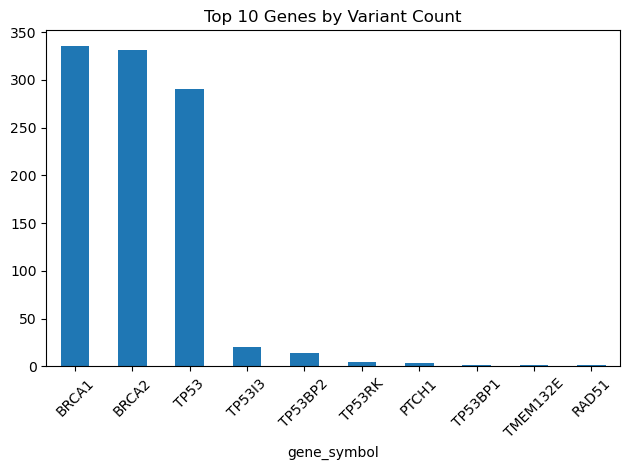

In [57]:
variant_gene_counts.head(10).plot(
    x = 'gene_symbol',
    y = 'variant_count',
    kind = 'bar',
    legend = False,
    title = 'Top 10 Genes by Variant Count'
)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

This plot shows the top genes by variant count, with BRCA1, BRCA2, and TP53 being the most represented.

## Plot 2: Annotation Status Distribution

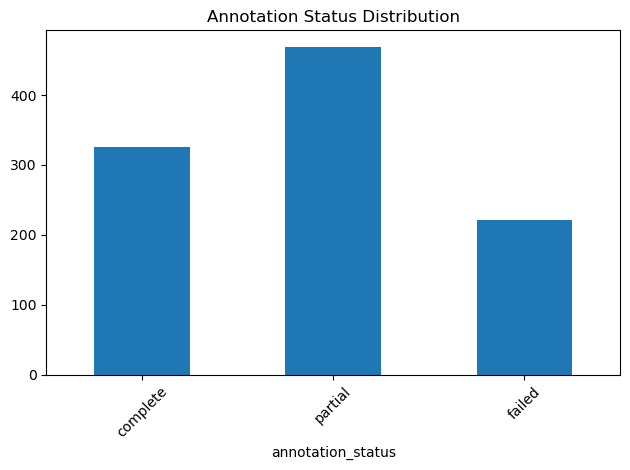

In [58]:
# Reorder for logical display
annotation_status_dist = annotation_status_dist.set_index('annotation_status').loc[
    ['complete', 'partial', 'failed']
].reset_index()

# Plot
annotation_status_dist.plot(
    x='annotation_status',
    y='count',
    kind='bar',
    legend=False,
    title='Annotation Status Distribution'
)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

This plot shows the distribution of annotation completeness across variants, with partial annotations being the most common, followed by complete and failed records.

## Plot 3: Mutation Type Distribution

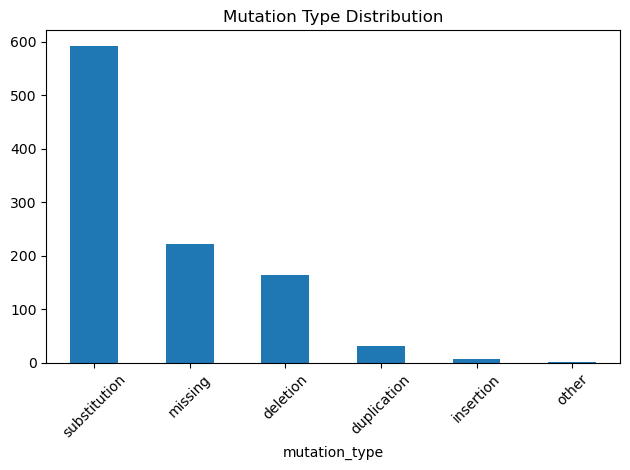

In [59]:
mutation_type_dist.plot(
    x='mutation_type',
    y='count',
    kind='bar',
    legend=False,
    title='Mutation Type Distribution'
)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

This plot shows that substitution mutations overwhelmingly dominate the dataset, with deletions as the second most common mutation type and all others occurring relatively infrequently.

### Streamlit Application (Extra Credit)

A Streamlit dashboard was developed to provide an interactive interface for exploring genomic variant data. Users can select a gene to dynamically update mutation distributions and view associated variant records.

The application code is included below. Screenshots of the running application are provided in the report.

In [60]:
%%writefile app.py

# Import required libraries for UI, data handling, database access, and visualization
import streamlit as st
import pandas as pd
import sqlite3
import altair as alt

# App title and description
st.title("Genomic Variant Dashboard")
st.markdown("Explore variant distributions and annotations by gene.")

# Connect to SQLite database and load data
conn = sqlite3.connect("variants.db")

# Query: total variant counts per gene (global summary)
variant_gene_counts = pd.read_sql("""
SELECT genes.gene_symbol,
COUNT(variants.variant_id) AS variant_count
FROM genes
JOIN variants
ON genes.gene_id = variants.gene_id
GROUP BY genes.gene_symbol
ORDER BY variant_count DESC;
""", conn)

# Query: overall mutation type distribution (not directly used but available if needed)
mutation_type_counts = pd.read_sql("""
SELECT mutation_type,
COUNT(*) AS count
FROM variants
GROUP BY mutation_type
ORDER BY count DESC;
""", conn)

# Query: full variant-level dataset for filtering and display
variants = pd.read_sql("""
SELECT variants.variant_id,
genes.gene_symbol,
variants.input,
variants.rsid,
variants.hgvsc,
variants.hgvsp,
variants.hgvsg,
variants.mutation_type
FROM variants
JOIN genes
ON genes.gene_id = variants.gene_id;
""", conn)

conn.close()

# User input to select gene
selected_gene = st.selectbox(
    "Select Gene",
    sorted(variants["gene_symbol"].unique())
)

# Filter dataset based on selected gene
filtered = variants[variants["gene_symbol"] == selected_gene]

# Display summary statistic for selected gene
st.write(f"Total variants for {selected_gene}: {len(filtered)}")

# Prepare mutation type distribution for selected gene
filtered_mutation_counts = (
    filtered["mutation_type"]
    .value_counts()
    .reset_index()
)

filtered_mutation_counts.columns = ["mutation_type", "count"]

# Layout is two-column dashboard view
col1, col2 = st.columns(2)

# Left chart: mutation type distribution for selected gene
with col1:
    st.subheader(f"Mutation Type Distribution for {selected_gene}")
    st.bar_chart(filtered_mutation_counts.set_index("mutation_type"))

# Right chart: overall gene variant counts with selected gene highlighted
with col2:
    st.subheader("Variant Counts by Gene")
    
    # Mark selected gene for highlighting
    gene_chart_data = variant_gene_counts.copy()
    gene_chart_data["selected"] = gene_chart_data["gene_symbol"] == selected_gene

    # Altair chart with conditional coloring
    gene_chart = alt.Chart(gene_chart_data).mark_bar().encode(
        x=alt.X("gene_symbol:N", sort="-y", title="Gene"),
        y=alt.Y("variant_count:Q", title="Variant Count"),
        color=alt.condition(
            alt.datum.selected,
            alt.value("magenta"),   # highlight selected gene
            alt.value("steelblue")  # default color
        ),
        tooltip=["gene_symbol", "variant_count"]
    ).properties(
        height=400
    )

    st.altair_chart(gene_chart, use_container_width=True)

# Display filtered variant records
st.subheader("Filtered Variant Records")
st.dataframe(filtered)

Overwriting app.py
